# CPPI: profitability and risk analysis (GBM vs Merton jumps) with sensitivity study and leverage cap

Authors : Johanna RAKOTOVAO, Eya GHORBEL, Ranim KNAISSI

### Imports and global configuration

In [ ]:
# 0) Imports and global configuration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

We set up the Python environment and fix a few display defaults to keep figures readable and consistent throughout the notebook. We rely only on `numpy/pandas/matplotlib` to keep everything simple, reproducible, and easy to verify.

### 1) Parameters

We centralize all parameters for the CPPI contract, the market model, and the Monte-Carlo simulation:

* guaranteed floor $N$ and initial wealth $V_0$ (here $V_0=N$) ;
* horizon $T$ and risk-free rate $r$ (continuous compounding) ;
* price model parameters: $(\mu,\sigma)$ for GBM and $(\lambda,\mu_J,\sigma_J)$ for Merton ;
* time granularity (daily base step: 252 days/year) ;
* Monte-Carlo size and grid of multiples $m$ ;
* rebalancing frequencies (daily/weekly/monthly) and the leverage-cap variant.

Transaction costs and borrowing spread are parameterized and can be switched on to assess their impact.

In [ ]:
# 1) Parameters

SEED = 12345
rng = np.random.default_rng(SEED)

# Contract / CPPI
N_GUARANTEE = 100.0      # N
V0 = 100.0               # initial wealth (here we take V0 = N)
T_YEARS = 5.0
RISK_FREE = 0.05         # r (continuously compounded)
BORROW_SPREAD = 0.00     # optional: extra rate when cash < 0
TCOST = 0.0              # proportional transaction costs (e.g. 0.0005 = 5 bps per trade)

# Market (GBM under P)
S0 = 100.0
MU = 0.08                # drift under P
SIGMA = 0.20

# Market (Merton Jump-Diffusion parameters)
LAMBDA_J = 1.0           # expected jumps per year
MU_J = -0.12             # mean of jump size in log (downward bias)
SIGMA_J = 0.18           # stdev of jump size in log

# Simulation granularity: "base" step = daily trading day
STEPS_PER_YEAR = 252
DT = 1.0 / STEPS_PER_YEAR
N_STEPS = int(T_YEARS * STEPS_PER_YEAR)

# Monte Carlo size
N_PATHS = 20000          # increase to 50000+ for smoother results (slower)

# CPPI multiples and rebalancing frequencies
M_GRID = np.array([1, 2, 3, 4, 5, 6], dtype=float)

REBAL_FREQ = {
    "Daily": 1,
    "Weekly": 5,
    "Monthly": 21,
}

# Variant: leverage cap (Et <= Lmax * Vt)
L_MAX_CAP = 1.5

### 2) Utility functions: floor, risk metrics, plotting utilities

We define utility functions used throughout the notebook:

* floor: $B_t = N e^{-r(T-t)}$, i.e., the present value of the guarantee at time $t$ ;
* loss-side risk via the shortfall variable $L = (N - V_T)^+$, then VaR/ES computed on $L$ ;
* max drawdown as a path-dependent risk measure ;
* empirical CDF to compare the distributions of $V_T$ across models.


In [ ]:
# 2) Utility functions

def floor_value(t: float, N: float, r: float, T: float) -> float:
    """
    Floor value at time t as PV of N at T:
        B_t = N * exp(-r*(T-t))
    """
    return N * np.exp(-r * (T - t))


def var_es(loss: np.ndarray, alpha: float = 0.99) -> Tuple[float, float]:
    """
    VaR/ES for a non-negative loss random variable.
    VaR_alpha = quantile at alpha
    ES_alpha  = E[loss | loss >= VaR_alpha] (tail mean)
    """
    q = np.quantile(loss, alpha)
    tail = loss[loss >= q]
    es = float(tail.mean()) if tail.size > 0 else float(q)
    return float(q), es


def max_drawdown(paths: np.ndarray) -> np.ndarray:
    """
    Max drawdown per path for a wealth process V_t (shape: n_paths x (n_steps+1)).
    drawdown_t = 1 - V_t / running_max_t
    return max drawdown in [0,1] per path.
    """
    running_max = np.maximum.accumulate(paths, axis=1)
    dd = 1.0 - paths / np.maximum(running_max, 1e-16)
    return dd.max(axis=1)


def empirical_cdf(x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    xs = np.sort(x)
    ys = np.arange(1, xs.size + 1) / xs.size
    return xs, ys

### 3) Simulators: GBM and Merton jump-diffusion (gross returns)

We simulate market paths under two models using gross returns
$$G_{k+1}=\frac{S_{k+1}}{S_k},$$
since CPPI only requires successive returns to update the risky sleeve.

* GBM (diffusion): exact log discretization
  $$\log G = \left(\mu-\tfrac12\sigma^2\right)\Delta t + \sigma\sqrt{\Delta t},Z.$$
* Merton jump-diffusion: log-return = diffusion + sum of jumps; we use a compensator $-\lambda\kappa$ with $\kappa=\mathbb{E}[e^Y-1]$ to keep the average drift consistent.

Gross returns avoid storing the full $S_t$ path and simplify the portfolio update (multiplicative update of the risky sleeve).

In [ ]:
# 3) Market simulators (gross returns)

def simulate_gbm_gross_returns(
    n_paths: int,
    n_steps: int,
    dt: float,
    mu: float,
    sigma: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    GBM:
        dS/S = mu dt + sigma dW
    Exact discretization in log:
        log(S_{t+dt}/S_t) = (mu - 0.5 sigma^2) dt + sigma sqrt(dt) Z
    Returns matrix G of shape (n_paths, n_steps).
    """
    z = rng.standard_normal(size=(n_paths, n_steps))
    log_g = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
    return np.exp(log_g)


def simulate_merton_gross_returns(
    n_paths: int,
    n_steps: int,
    dt: float,
    mu: float,
    sigma: float,
    lam: float,
    mu_j: float,
    sigma_j: float,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Merton Jump-Diffusion in log:
        dS/S = mu dt + sigma dW + (e^Y - 1) dN   (in integrated form)
    Discrete:
        log(S_{t+dt}/S_t) = (mu - 0.5 sigma^2 - lam*kappa) dt + sigma sqrt(dt) Z + sum_{i=1}^{N} Y_i
    with Y_i ~ N(mu_j, sigma_j^2), N ~ Poisson(lam dt),
    and kappa = E[e^Y - 1] = exp(mu_j + 0.5 sigma_j^2) - 1.

    This compensator makes E[dS/S] approximately mu dt.
    Returns gross returns matrix G of shape (n_paths, n_steps).
    """
    z = rng.standard_normal(size=(n_paths, n_steps))
    n_jumps = rng.poisson(lam=lam * dt, size=(n_paths, n_steps))

    kappa = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0
    drift = (mu - 0.5 * sigma**2 - lam * kappa) * dt

    # Sum of N normals: Normal(N*mu_j, sqrt(N)*sigma_j).
    # When n_jumps=0, scale=0 would cause a ValueError; we handle this safely.
    safe_scale = sigma_j * np.sqrt(np.maximum(n_jumps, 1))
    raw_jump = rng.normal(loc=n_jumps * mu_j, scale=safe_scale)
    jump_term = np.where(n_jumps > 0, raw_jump, 0.0)

    log_g = drift + sigma * np.sqrt(dt) * z + jump_term
    return np.exp(log_g)

### 4) CPPI engine (discrete rebalancing) + metrics

We implement CPPI in discrete time with periodic rebalancing.

### Discrete CPPI rule

At a rebalancing date $t_k$:

* floor: $B_{t_k}=N e^{-r(T-t_k)}$ ;
* cushion: $C_{t_k}=\max(V_{t_k}-B_{t_k},0)$ ;
* risky exposure (amount): $E_{t_k}=m\,C_{t_k}$ ;
* cash: $M_{t_k}=V_{t_k}-E_{t_k}$ (can be negative under leverage).

Between rebalancing dates:

* risky sleeve evolves via $E\leftarrow E\cdot G$ ;
* cash evolves via $M\leftarrow M\cdot e^{r\Delta t}$ (and $r+$spread if $M<0$ when borrowing costs are enabled).

### Failure event

At an observation date (here, rebalancing dates), if $V_{t_k} < B_{t_k}$, we treat the floor as breached and lock the portfolio into 100% risk-free thereafter.

### Leverage-cap variant

We can impose
$$E_{t_k}\le L_{\max}V_{t_k},$$
which limits exposure.

### Reported metrics

We compute:

* $\mathbb{E}[V_T]$, median, quantiles ;
* $\mathbb{P}(V_T<N)$ and $\mathbb{E}[(N-V_T)^+]$ ;
* VaR/ES of shortfall ;
* max drawdown, time-in-cash (proxy) ;
* turnover (proxy for trading costs).


In [ ]:
# 4) CPPI engine


@dataclass
class CPPIResult:
    V_paths: Optional[np.ndarray]      # (n_paths, n_steps+1) if stored
    V_T: np.ndarray                    # (n_paths,)
    shortfall: np.ndarray              # (n_paths,) (N - V_T)^+
    metrics: Dict[str, float]


def run_cppi(
    gross_returns: np.ndarray,
    m: float,
    N: float,
    V0: float,
    r: float,
    T: float,
    dt: float,
    rebalance_every: int,
    borrow_spread: float = 0.0,
    tcost: float = 0.0,
    leverage_cap: Optional[float] = None,
    store_paths: bool = True,
) -> CPPIResult:
    """
    CPPI with discrete rebalancing on a base grid (dt) and rebalancing every 'rebalance_every' steps.

    State variables (amounts):
        E = risky allocation amount
        M = cash amount (can be negative)

    Evolution between base steps:
        E <- E * G
        M <- M * exp((r or r+spread)*dt)
        V <- E + M

    Rebalancing (only at rebalance dates):
        B_t = N * exp(-r*(T-t))
        if V < B_t => fail => set E=0, M=V permanently
        else:
            C = V - B_t
            E_target = m * C
            if leverage_cap: E_target = min(E_target, leverage_cap * V)
            transaction cost ~ tcost * |E_target - E|
            update V and set M = V - E_target

    Outputs:
        V_T, shortfall, and summary metrics.
    """
    n_paths, n_steps = gross_returns.shape

    if store_paths:
        V_paths = np.empty((n_paths, n_steps + 1), dtype=float)
        V_paths[:, 0] = V0
    else:
        V_paths = None

    # Initial rebalancing at t=0
    t0 = 0.0
    B0 = floor_value(t0, N, r, T)
    C0 = np.maximum(V0 - B0, 0.0)

    E = m * C0 * np.ones(n_paths, dtype=float)
    if leverage_cap is not None:
        E = np.minimum(E, leverage_cap * V0)

    M = V0 - E

    failed = np.zeros(n_paths, dtype=bool)

    # Turnover tracking (total traded notional)
    turnover = np.zeros(n_paths, dtype=float)

    # Time-in-cash proxy (fraction of base steps with low risky weight)
    # Here: count steps where E/V < 5%
    cash_like_steps = np.zeros(n_paths, dtype=int)
    total_steps = 0

    # Precompute time grid (for floor)
    times = np.linspace(0.0, T, n_steps + 1)

    for k in range(n_steps):
        # 1) evolve one base step
        G = gross_returns[:, k]

        # risky leg
        E = E * G

        # cash leg with optional borrowing spread
        cash_rate = np.where(M < 0.0, r + borrow_spread, r)
        M = M * np.exp(cash_rate * dt)

        V = E + M

        if store_paths:
            V_paths[:, k + 1] = V

        # time-in-cash proxy
        total_steps += 1
        w_risky = np.where(V > 0.0, E / V, 0.0)
        cash_like_steps += (w_risky < 0.05).astype(int)

        # 2) rebalance if needed (skip rebalancing at final point: optional; here we do rebalance at scheduled dates except last)
        is_rebal_date = ((k + 1) % rebalance_every == 0) and (k + 1 < n_steps)

        if not is_rebal_date:
            continue

        t = times[k + 1]
        B = floor_value(t, N, r, T)

        # Detect failure at observation date
        newly_failed = (~failed) & (V < B)
        if np.any(newly_failed):
            failed[newly_failed] = True
            E[newly_failed] = 0.0
            M[newly_failed] = V[newly_failed]
            # No further rebalancing for these paths (they just accrue at r)

        # Rebalance only for alive paths
        alive = ~failed
        if not np.any(alive):
            continue

        V_a = V[alive]
        E_a = E[alive]

        C = np.maximum(V_a - B, 0.0)
        E_target = m * C

        if leverage_cap is not None:
            E_target = np.minimum(E_target, leverage_cap * V_a)

        trade = E_target - E_a
        cost = tcost * np.abs(trade)

        # Pay costs from wealth (simplified)
        V_a_net = V_a - cost

        # If costs push below the floor, treat as failure at that date
        fail_after_cost = V_a_net < B
        if np.any(fail_after_cost):
            idx_alive = np.where(alive)[0]
            idx_fail = idx_alive[fail_after_cost]
            failed[idx_fail] = True
            E[idx_fail] = 0.0
            M[idx_fail] = V_a_net[fail_after_cost]
            # Remove those from further rebalancing computations
            keep = ~fail_after_cost
        else:
            keep = slice(None)

        # Update allocations for surviving alive paths
        if np.any(keep) if not isinstance(keep, slice) else True:
            if isinstance(keep, slice):
                idx_keep = np.where(alive)[0]
                V_keep = V_a_net
                E_keep = E_target
                trade_keep = trade
            else:
                idx_alive = np.where(alive)[0]
                idx_keep = idx_alive[keep]
                V_keep = V_a_net[keep]
                E_keep = E_target[keep]
                trade_keep = trade[keep]

            # Update turnover
            turnover[idx_keep] += np.abs(trade_keep)

            E[idx_keep] = E_keep
            M[idx_keep] = V_keep - E_keep

            if store_paths:
                # overwrite stored V after cost (optional but coherent for drawdown)
                V_paths[idx_keep, k + 1] = V_keep

    # Terminal wealth
    if store_paths:
        V_T = V_paths[:, -1]
    else:
        V_T = E + M  # already at final step

    shortfall = np.maximum(N - V_T, 0.0)

    # Metrics
    p_short = float(np.mean(V_T < N))
    exp_vt = float(np.mean(V_T))
    med_vt = float(np.median(V_T))
    q05 = float(np.quantile(V_T, 0.05))
    q01 = float(np.quantile(V_T, 0.01))

    exp_short = float(np.mean(shortfall))
    var99, es99 = var_es(shortfall, alpha=0.99)

    if store_paths:
        mdd = max_drawdown(V_paths)
        mdd_mean = float(np.mean(mdd))
        mdd_q95 = float(np.quantile(mdd, 0.95))
    else:
        mdd_mean = np.nan
        mdd_q95 = np.nan

    time_in_cash = float(np.mean(cash_like_steps / max(total_steps, 1)))
    turnover_mean = float(np.mean(turnover / V0))  # turnover scaled by initial wealth

    metrics = {
        "E[V_T]": exp_vt,
        "Median(V_T)": med_vt,
        "Q05(V_T)": q05,
        "Q01(V_T)": q01,
        "P(V_T < N)": p_short,
        "E[(N - V_T)+]": exp_short,
        "VaR_99(shortfall)": var99,
        "ES_99(shortfall)": es99,
        "Time_in_cash(<5% risky)": time_in_cash,
        "Turnover / V0": turnover_mean,
        "MDD_mean": mdd_mean,
        "MDD_q95": mdd_q95,
    }

    return CPPIResult(V_paths=V_paths, V_T=V_T, shortfall=shortfall, metrics=metrics)

### 5) Generate market scenarios (GBM and Jump)

We generate a single Monte-Carlo scenario base shared by all experiments. We first simulate GBM gross returns, then Merton gross returns with a different seed. All CPPI runs reuse these same return matrices.

In [ ]:
# 5) Market scenarios

G_gbm = simulate_gbm_gross_returns(
    n_paths=N_PATHS,
    n_steps=N_STEPS,
    dt=DT,
    mu=MU,
    sigma=SIGMA,
    rng=rng,
)

# Use a fresh RNG stream for the jump model for reproducibility separation
rng_jump = np.random.default_rng(SEED + 1)

G_jump = simulate_merton_gross_returns(
    n_paths=N_PATHS,
    n_steps=N_STEPS,
    dt=DT,
    mu=MU,
    sigma=SIGMA,
    lam=LAMBDA_J,
    mu_j=MU_J,
    sigma_j=SIGMA_J,
    rng=rng_jump,
)

print("Shapes:", G_gbm.shape, G_jump.shape)

Shapes: (20000, 1260) (20000, 1260)


We simulate $20{,}000$ paths on a daily grid ($252$ steps/year), i.e. $1260$ steps over $T=5$ years.

### 6) Core experiment: $\mathbb{P}(V_T < N)$ versus multiple $m$ across rebalancing frequencies

We quantify the joint impact of the multiple $m$ and rebalancing frequency on shortfall risk. We fix a market model (GBM, then Merton), sweep $m\in{1,2,3,4,5,6}$, and repeat for several frequencies (daily/weekly/monthly).

We store:

* $\mathbb{P}(V_T<N)$: estimated probability that terminal wealth ends below the guarantee $N$.
* $\mathbb{E}[V_T]$: mean terminal wealth, i.e. average upside at maturity.
* $\mathbb{E}[(N-V_T)^+]$: mean shortfall, i.e. average severity of losses below the floor (expected shortfall amount in currency units).


In [ ]:
# 6) P(VT < N) vs m for different rebalancing frequencies

def sweep_prob_shortfall(
    gross_returns: np.ndarray,
    model_name: str,
    m_grid: np.ndarray,
    rebal_freq: Dict[str, int],
    leverage_cap: Optional[float] = None,
) -> pd.DataFrame:
    rows = []
    for freq_name, every in rebal_freq.items():
        for m in m_grid:
            res = run_cppi(
                gross_returns=gross_returns,
                m=float(m),
                N=N_GUARANTEE,
                V0=V0,
                r=RISK_FREE,
                T=T_YEARS,
                dt=DT,
                rebalance_every=every,
                borrow_spread=BORROW_SPREAD,
                tcost=TCOST,
                leverage_cap=leverage_cap,
                store_paths=False,  # faster for sweeps
            )
            rows.append({
                "Model": model_name,
                "Frequency": freq_name,
                "rebalance_every": every,
                "m": float(m),
                "P_shortfall": res.metrics["P(V_T < N)"],
                "E_VT": res.metrics["E[V_T]"],
                "E_shortfall": res.metrics["E[(N - V_T)+]"],
            })
    return pd.DataFrame(rows)

df_prob_gbm = sweep_prob_shortfall(G_gbm, "GBM", M_GRID, REBAL_FREQ, leverage_cap=None)
df_prob_jump = sweep_prob_shortfall(G_jump, "Jump(Merton)", M_GRID, REBAL_FREQ, leverage_cap=None)

df_prob = pd.concat([df_prob_gbm, df_prob_jump], ignore_index=True)
df_prob.head()

,Model,Frequency,rebalance_every,m,P_shortfall,E_VT,E_shortfall
0,GBM,Daily,1,1.0,0.0,132.893732,0.0
1,GBM,Daily,1,2.0,0.0,137.983726,0.0
2,GBM,Daily,1,3.0,0.0,143.632029,0.0
3,GBM,Daily,1,4.0,0.0,149.563889,0.0
4,GBM,Daily,1,5.0,0.0,155.062445,0.0


In [ ]:
df_prob.tail()

,Model,Frequency,rebalance_every,m,P_shortfall,E_VT,E_shortfall
31,Jump(Merton),Monthly,21,2.0,0.01335,138.458175,0.034174
32,Jump(Merton),Monthly,21,3.0,0.27205,144.872664,1.970034
33,Jump(Merton),Monthly,21,4.0,0.58560,153.397904,11.186930
34,Jump(Merton),Monthly,21,5.0,0.74805,166.714246,33.100026
35,Jump(Merton),Monthly,21,6.0,0.83255,192.034931,74.783431


The sweep already shows the regime change: near-zero shortfall in GBM at high rebalancing frequency, versus large shortfall probabilities and severities in the jump model as $m$ increases.

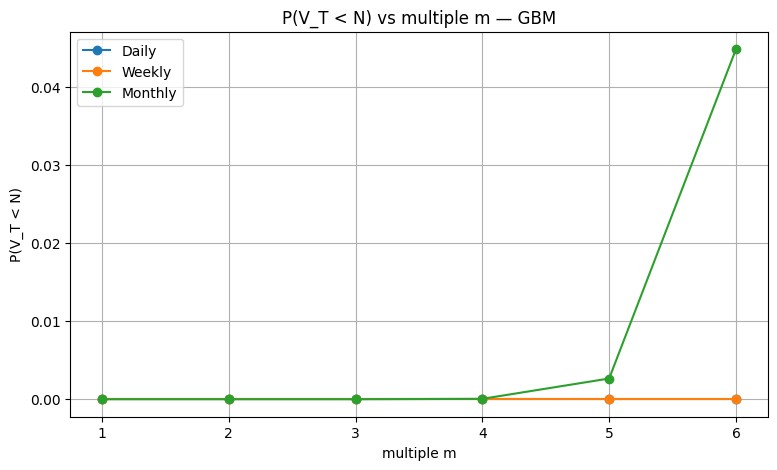

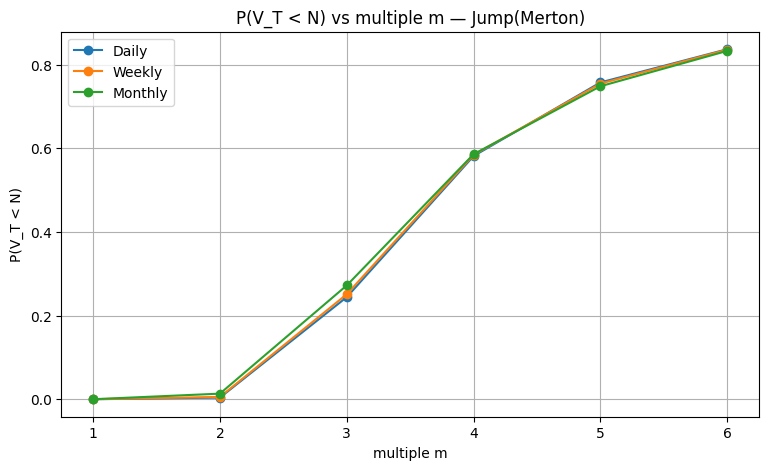

In [ ]:
# Plot P(shortfall) vs m

def plot_prob_shortfall(df: pd.DataFrame, model: str):
    sub = df[df["Model"] == model]
    plt.figure()
    for freq in REBAL_FREQ.keys():
        s = sub[sub["Frequency"] == freq].sort_values("m")
        plt.plot(s["m"], s["P_shortfall"], marker="o", label=freq)
    plt.title(f"P(V_T < N) vs multiple m — {model}")
    plt.xlabel("multiple m")
    plt.ylabel("P(V_T < N)")
    plt.legend()
    plt.show()

plot_prob_shortfall(df_prob, "GBM")
plot_prob_shortfall(df_prob, "Jump(Merton)")

In GBM, shortfall risk is mainly driven by discrete rebalancing: it remains undetected for daily/weekly rebalancing at this Monte-Carlo size, while monthly rebalancing shows visible shortfall for large $m$.

In the jump model, shortfall probability increases sharply with $m$ and is only weakly affected by rebalancing frequency, consistent with a ‘single large jump’ mechanism.

### 7) Distributions of $V_T$ : histogram + empirical CDF (GBM vs Jump)


We compare the full terminal distribution. For two values of $m$, we plot:

* a histogram of $V_T$ ;
* the empirical CDF of $V_T$.

We also display a vertical line at $N$ to visualize the mass below the guarantee.

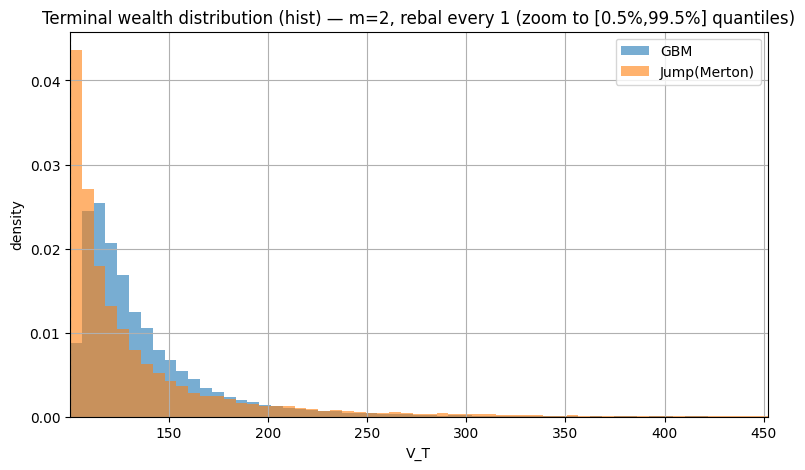

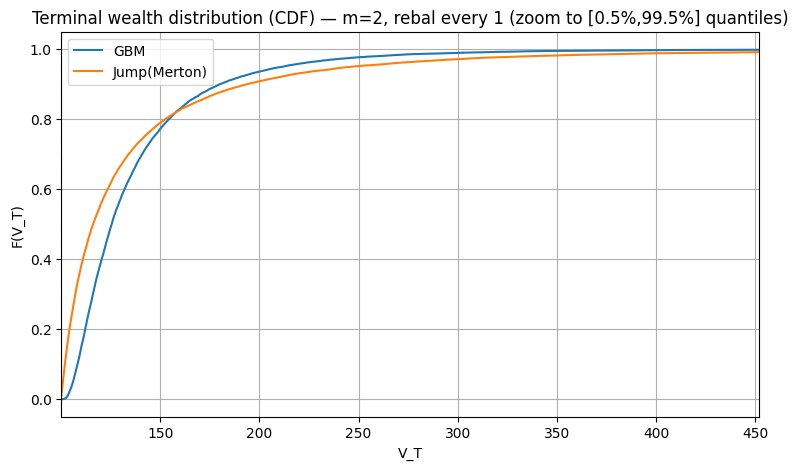

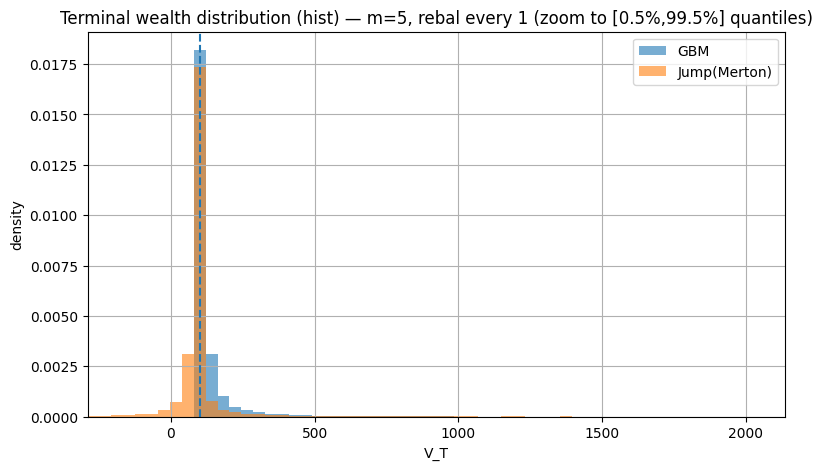

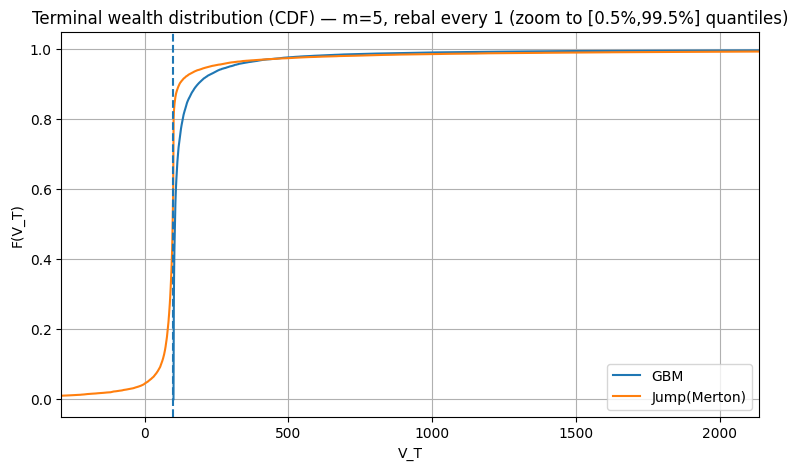

In [ ]:
# 7) Distribution plots for VT

def compare_distributions(gbm_returns, jump_returns, m_values=(2, 5), rebalance_every=1,
                          q_lo: float = 0.005, q_hi: float = 0.995):
    """
    Compare terminal wealth distributions with a quantile-based x-axis zoom to avoid
    outlier-driven scaling (typical with leverage + jumps).
    """
    for m in m_values:
        res_g = run_cppi(
            gross_returns=gbm_returns, m=float(m),
            N=N_GUARANTEE, V0=V0, r=RISK_FREE, T=T_YEARS, dt=DT,
            rebalance_every=rebalance_every, borrow_spread=BORROW_SPREAD, tcost=TCOST,
            leverage_cap=None, store_paths=False
        )
        res_j = run_cppi(
            gross_returns=jump_returns, m=float(m),
            N=N_GUARANTEE, V0=V0, r=RISK_FREE, T=T_YEARS, dt=DT,
            rebalance_every=rebalance_every, borrow_spread=BORROW_SPREAD, tcost=TCOST,
            leverage_cap=None, store_paths=False
        )

        # Quantile zoom limits computed on the pooled sample (so both hist share the same x-scale)
        vt_all = np.concatenate([res_g.V_T, res_j.V_T])
        x_min = float(np.quantile(vt_all, q_lo))
        x_max = float(np.quantile(vt_all, q_hi))
        if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min >= x_max:
            x_min, x_max = float(vt_all.min()), float(vt_all.max())

        bins = np.linspace(x_min, x_max, 60)

        # Histogram (zoomed)
        plt.figure()
        plt.hist(res_g.V_T, bins=bins, alpha=0.6, density=True, label="GBM")
        plt.hist(res_j.V_T, bins=bins, alpha=0.6, density=True, label="Jump(Merton)")
        plt.axvline(N_GUARANTEE, linestyle="--", color="red", linewidth=1.5, label=f"Guarantee N={N_GUARANTEE}")
        plt.xlim(x_min, x_max)
        plt.title(f"Terminal wealth distribution (hist) — m={m}, rebal every {rebalance_every}"
                  f" (zoom to [{q_lo:.1%},{q_hi:.1%}] quantiles)")
        plt.xlabel("V_T")
        plt.ylabel("density")
        plt.legend()
        plt.show()

        # CDF (same zoom)
        xg, yg = empirical_cdf(res_g.V_T)
        xj, yj = empirical_cdf(res_j.V_T)

        plt.figure()
        plt.plot(xg, yg, label="GBM")
        plt.plot(xj, yj, label="Jump(Merton)")
        plt.axvline(N_GUARANTEE, linestyle="--", color="red", linewidth=1.5, label=f"Guarantee N={N_GUARANTEE}")
        plt.xlim(x_min, x_max)
        plt.title(f"Terminal wealth distribution (CDF) — m={m}, rebal every {rebalance_every}"
                  f" (zoom to [{q_lo:.1%},{q_hi:.1%}] quantiles)")
        plt.xlabel("V_T")
        plt.ylabel("F(V_T)")
        plt.legend()
        plt.show()

compare_distributions(G_gbm, G_jump, m_values=(2, 5), rebalance_every=1, q_lo=0.005, q_hi=0.995)

Due to rare but extreme outcomes under leverage and jumps, we use quantile-based zooming to keep the bulk of the distribution readable.

### 8) Heatmap of shortfall probability $\mathbb{P}(V_T < N)$ across $m$ and rebalancing frequency


We build a heatmap summarizing
$$(m,\Delta)\ \mapsto\ \mathbb{P}(V_T<N),$$
where $\Delta$ represents the rebalancing frequency. The heatmap compresses the joint effect of these two parameters into a single figure.


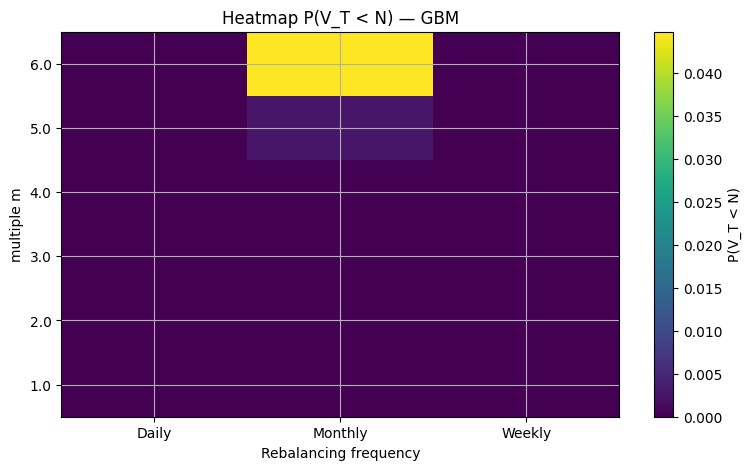

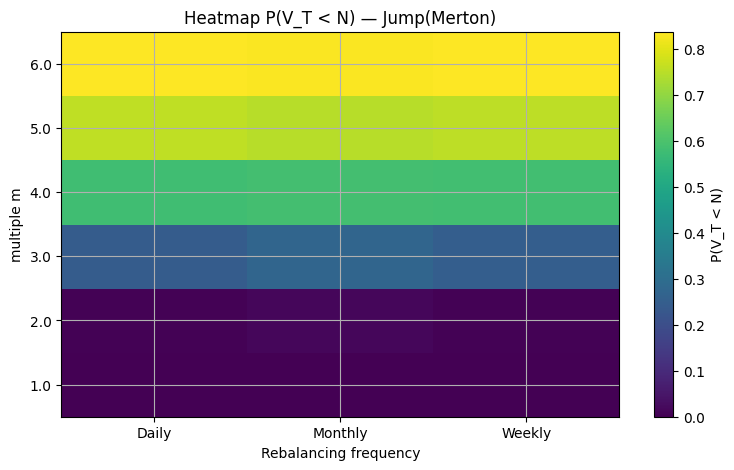

In [ ]:
# 8) Heatmap of P(shortfall)

def heatmap_prob_shortfall(df: pd.DataFrame, model: str):
    sub = df[df["Model"] == model].copy()
    pivot = sub.pivot(index="m", columns="Frequency", values="P_shortfall").reindex(index=M_GRID)
    plt.figure()
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.xticks(range(pivot.shape[1]), pivot.columns)
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.colorbar(label="P(V_T < N)")
    plt.title(f"Heatmap P(V_T < N) — {model}")
    plt.xlabel("Rebalancing frequency")
    plt.ylabel("multiple m")
    plt.show()

heatmap_prob_shortfall(df_prob, "GBM")
heatmap_prob_shortfall(df_prob, "Jump(Merton)")

The heatmaps summarize the joint sensitivity: in GBM the risk concentrates in low-frequency rebalancing with large $m$, while in the jump model $m$ dominates.

### 9) Leverage cap variant: $E_t \le L_{\max}V_t$ versus vanilla CPPI

Under the jump model, we compare:

* vanilla CPPI: $E=mC$ ;
* capped CPPI: $E=\min(mC, L_{\max}V)$.

We then plot risk indicators ($\mathbb{P}(V_T<N)$) and profitability ($\mathbb{E}[V_T]$) versus $m$ to visualize the trade-off.

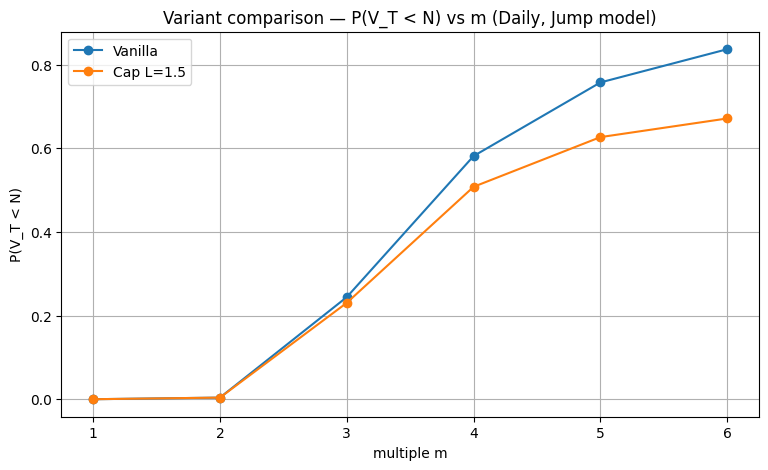

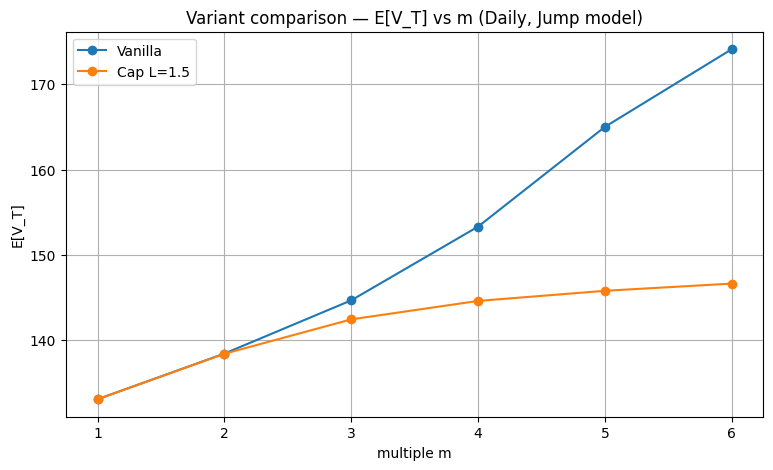

In [ ]:
# 9) Leverage cap variant vs vanilla

df_prob_jump_cap = sweep_prob_shortfall(
    gross_returns=G_jump,
    model_name=f"Jump(Merton) cap L={L_MAX_CAP}",
    m_grid=M_GRID,
    rebal_freq=REBAL_FREQ,
    leverage_cap=L_MAX_CAP,
)

df_compare = pd.concat([df_prob_jump, df_prob_jump_cap], ignore_index=True)

def plot_variant_comparison(df: pd.DataFrame, freq_name="Daily"):
    plt.figure()
    sub_van = df[(df["Model"] == "Jump(Merton)") & (df["Frequency"] == freq_name)].sort_values("m")
    sub_cap = df[(df["Model"].str.contains("cap")) & (df["Frequency"] == freq_name)].sort_values("m")

    plt.plot(sub_van["m"], sub_van["P_shortfall"], marker="o", label="Vanilla")
    plt.plot(sub_cap["m"], sub_cap["P_shortfall"], marker="o", label=f"Cap L={L_MAX_CAP}")
    plt.title(f"Variant comparison — P(V_T < N) vs m ({freq_name}, Jump model)")
    plt.xlabel("multiple m")
    plt.ylabel("P(V_T < N)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(sub_van["m"], sub_van["E_VT"], marker="o", label="Vanilla")
    plt.plot(sub_cap["m"], sub_cap["E_VT"], marker="o", label=f"Cap L={L_MAX_CAP}")
    plt.title(f"Variant comparison — E[V_T] vs m ({freq_name}, Jump model)")
    plt.xlabel("multiple m")
    plt.ylabel("E[V_T]")
    plt.legend()
    plt.show()

plot_variant_comparison(df_compare, freq_name="Daily")

Adding a leverage cap reduces shortfall risk markedly for large $m$, at the cost of a lower mean terminal wealth.

### 10) OBPI (Option-Based Portfolio Insurance): implementation and comparison

We implement a simple OBPI benchmark on the same horizon $T$: we invest $N e^{-rT}$ in a risk-free zero-coupon bond to guarantee $N$ at maturity and use the remaining budget to buy $\alpha$ European calls on the risky asset.

The terminal payoff is
$$V_T^{\mathrm{OBPI}} = N + \alpha\,(S_T-K)^+,$$
where $\alpha$ is determined by the initial budget constraint
$$\alpha = \frac{V_0 - N e^{-rT}}{C_0} \quad (\alpha=0 \text{ if } V_0 \le N e^{-rT}),$$
and $C_0$ is the time-0 call price.

We price the call under Black–Scholes with parameters $(r,\sigma)$ and fix the strike to an at-the-money contract $K=S_0$. We then evaluate the resulting payoff under the simulated physical scenarios (GBM and Merton) and compare CPPI and OBPI using terminal-wealth and shortfall metrics.

In [ ]:
# 10) OBPI (Option-Based Portfolio Insurance)

def bs_call_price(S0: float, K: float, T: float, r: float, sigma: float) -> float:
    """
    Black–Scholes call price (no dividends), using only the standard library.
    """
    from math import log, sqrt, exp, erf

    def norm_cdf(x: float) -> float:
        return 0.5 * (1.0 + erf(x / sqrt(2.0)))

    if T <= 0.0:
        return max(S0 - K, 0.0)
    if sigma <= 0.0:
        return max(S0 - K * exp(-r * T), 0.0)

    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S0 * norm_cdf(d1) - K * exp(-r * T) * norm_cdf(d2)


def obpi_terminal_wealth(
    S_T: np.ndarray,
    V0: float,
    N: float,
    T: float,
    r: float,
    S0: float,
    sigma: float,
    K: float,
) -> np.ndarray:
    """
    OBPI:
      - buy a zero-coupon bond to guarantee N at T (cost = N*exp(-rT))
      - spend remaining budget on alpha calls (ATM by default if K=S0)

    Terminal wealth:
      V_T = N + alpha * (S_T - K)^+
    where alpha = (V0 - PV(N)) / C0  (if positive; otherwise alpha=0).
    """
    pvN = N * np.exp(-r * T)
    C0 = bs_call_price(S0=S0, K=K, T=T, r=r, sigma=sigma)

    budget = V0 - pvN
    alpha = max(budget / C0, 0.0) if C0 > 0.0 else 0.0

    payoff = np.maximum(S_T - K, 0.0)
    return N + alpha * payoff


def terminal_price_from_gross_returns(S0: float, gross_returns: np.ndarray) -> np.ndarray:
    """
    Convert gross returns G_{k+1}=S_{k+1}/S_k into terminal price S_T per path.
    """
    return S0 * np.prod(gross_returns, axis=1)




We treat OBPI as a budget-matched benchmark (call priced once at time 0), then evaluate the resulting payoff under the simulated physical scenarios.

In [ ]:
# Compute OBPI terminal wealth on the same scenarios (GBM and Jump)

K_OBPI = S0  # ATM strike

S_T_gbm = terminal_price_from_gross_returns(S0, G_gbm)
S_T_jump = terminal_price_from_gross_returns(S0, G_jump)

V_T_obpi_gbm = obpi_terminal_wealth(
    S_T=S_T_gbm,
    V0=V0,
    N=N_GUARANTEE,
    T=T_YEARS,
    r=RISK_FREE,
    S0=S0,
    sigma=SIGMA,
    K=K_OBPI,
)

V_T_obpi_jump = obpi_terminal_wealth(
    S_T=S_T_jump,
    V0=V0,
    N=N_GUARANTEE,
    T=T_YEARS,
    r=RISK_FREE,
    S0=S0,
    sigma=SIGMA,   # pricing vol kept consistent with the diffusion vol parameter
    K=K_OBPI,
)


In [ ]:

# Compare against CPPI for one representative configuration (daily, picking m=4 by default)

M_OBPI_COMPARE = 4.0
res_cppi_gbm = run_cppi(
    gross_returns=G_gbm, m=M_OBPI_COMPARE,
    N=N_GUARANTEE, V0=V0, r=RISK_FREE, T=T_YEARS, dt=DT,
    rebalance_every=REBAL_FREQ["Daily"],
    borrow_spread=BORROW_SPREAD, tcost=TCOST,
    leverage_cap=None, store_paths=False
)
res_cppi_jump = run_cppi(
    gross_returns=G_jump, m=M_OBPI_COMPARE,
    N=N_GUARANTEE, V0=V0, r=RISK_FREE, T=T_YEARS, dt=DT,
    rebalance_every=REBAL_FREQ["Daily"],
    borrow_spread=BORROW_SPREAD, tcost=TCOST,
    leverage_cap=None, store_paths=False
)

def summarize_terminal(VT: np.ndarray, N: float) -> Dict[str, float]:
    shortfall = np.maximum(N - VT, 0.0)
    var99, es99 = var_es(shortfall, alpha=0.99)
    return {
        "E[V_T]": float(np.mean(VT)),
        "Median(V_T)": float(np.median(VT)),
        "Q05(V_T)": float(np.quantile(VT, 0.05)),
        "P(V_T < N)": float(np.mean(VT < N)),
        "E[(N - V_T)+]": float(np.mean(shortfall)),
        "VaR_99(shortfall)": float(var99),
        "ES_99(shortfall)": float(es99),
    }

df_obpi_compare = pd.DataFrame([
    {"Model": "GBM", "Strategy": f"CPPI (m={M_OBPI_COMPARE}, daily)", **summarize_terminal(res_cppi_gbm.V_T, N_GUARANTEE)},
    {"Model": "GBM", "Strategy": "OBPI (bond + ATM call)", **summarize_terminal(V_T_obpi_gbm, N_GUARANTEE)},
    {"Model": "Jump(Merton)", "Strategy": f"CPPI (m={M_OBPI_COMPARE}, daily)", **summarize_terminal(res_cppi_jump.V_T, N_GUARANTEE)},
    {"Model": "Jump(Merton)", "Strategy": "OBPI (bond + ATM call)", **summarize_terminal(V_T_obpi_jump, N_GUARANTEE)},
])

df_obpi_compare

,Model,Strategy,E[V_T],Median(V_T),Q05(V_T),P(V_T < N),E[(N - V_T)+],VaR_99(shortfall),ES_99(shortfall)
0,GBM,"CPPI (m=4.0, daily)",149.563889,110.199843,100.563762,0.0000,0.000000,0.00000,0.000000
1,GBM,OBPI (bond + ATM call),141.074070,126.044241,100.000000,0.0000,0.000000,0.00000,0.000000
2,Jump(Merton),"CPPI (m=4.0, daily)",153.309681,99.747235,63.988557,0.5812,9.953624,139.08849,396.734057
3,Jump(Merton),OBPI (bond + ATM call),147.094563,118.978441,100.000000,0.0000,0.000000,0.00000,0.000000


OBPI (bond + ATM call) delivers a hard floor at maturity ($V_T\ge N$ by construction), while CPPI can breach the floor under jumps when large downward moves occur between rebalancing dates.

We visualize the comparison by plotting the terminal wealth distributions for CPPI (fixed $m$, daily) and OBPI on each model. A vertical line at $N$ highlights the mass below the guarantee.

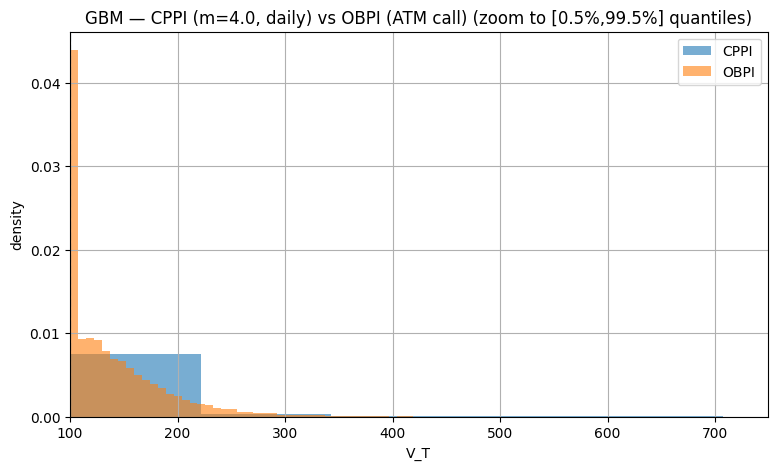

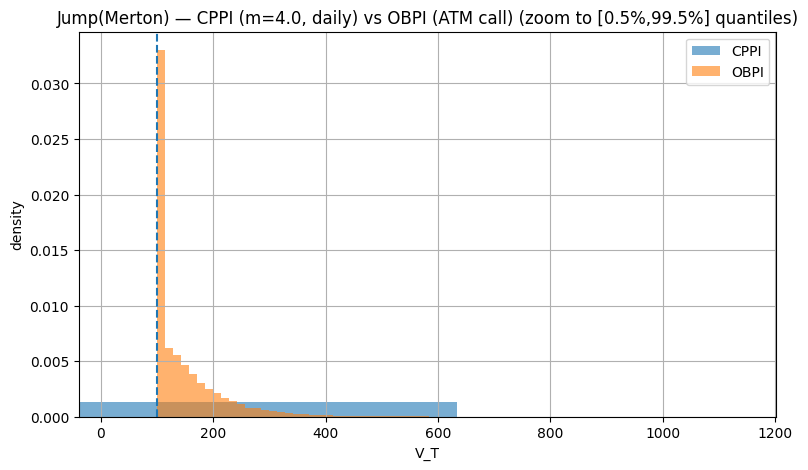

In [ ]:
#  Distribution comparison: CPPI vs OBPI (GBM and Jump)

def plot_cppi_vs_obpi_hist(VT_cppi: np.ndarray, VT_obpi: np.ndarray, title: str,  q_lo: float = 0.005, q_hi: float = 0.995):
    """
    Histogram comparison with a quantile-based x-axis limit to avoid outlier-driven scaling.
    """
    vt_all = np.concatenate([VT_cppi, VT_obpi])
    x_min = float(np.quantile(vt_all, q_lo))
    x_max = float(np.quantile(vt_all, q_hi))

    plt.figure()
    plt.hist(VT_cppi, bins=60, alpha=0.6, density=True, label="CPPI")
    plt.hist(VT_obpi, bins=60, alpha=0.6, density=True, label="OBPI")
    plt.axvline(N_GUARANTEE, linestyle="--", color="red", linewidth=1.5, label=f"Guarantee N={N_GUARANTEE}")
    plt.xlim(x_min, x_max)
    plt.title(title + f" (zoom to [{q_lo:.1%},{q_hi:.1%}] quantiles)")
    plt.xlabel("V_T")
    plt.ylabel("density")
    plt.legend()
    plt.show()

plot_cppi_vs_obpi_hist(
    VT_cppi=res_cppi_gbm.V_T,
    VT_obpi=V_T_obpi_gbm,
    title=f"GBM — CPPI (m={M_OBPI_COMPARE}, daily) vs OBPI (ATM call)"
)

plot_cppi_vs_obpi_hist(
    VT_cppi=res_cppi_jump.V_T,
    VT_obpi=V_T_obpi_jump,
    title=f"Jump(Merton) — CPPI (m={M_OBPI_COMPARE}, daily) vs OBPI (ATM call)"
)

Under GBM, both strategies remain above the guarantee in this simulation, but CPPI exhibits a more right-skewed terminal distribution (higher mean, lower median) than OBPI.

Under Merton jumps, CPPI shows substantial mass below $N$ (gap risk), whereas OBPI stays above $N$ at maturity, highlighting the difference between dynamic insurance and option-based insurance.

### 11) Summary table — CPPI and OBPI comparison

We build a summary table for a few representative configurations (e.g., $m=2,4,6$ with daily rebalancing) with richer metrics. We set `store_paths=True` to compute path-dependent quantities (max drawdown), then aggregate results in a single table.

In [ ]:
# 11) Summary table of metrics for selected cases (store paths)


def run_and_collect(
    gross_returns: np.ndarray,
    label: str,
    m: float,
    freq_name: str,
    leverage_cap: Optional[float] = None,
) -> Dict[str, float]:
    every = REBAL_FREQ[freq_name]
    res = run_cppi(
        gross_returns=gross_returns,
        m=m,
        N=N_GUARANTEE,
        V0=V0,
        r=RISK_FREE,
        T=T_YEARS,
        dt=DT,
        rebalance_every=every,
        borrow_spread=BORROW_SPREAD,
        tcost=TCOST,
        leverage_cap=leverage_cap,
        store_paths=True,
    )
    out = {"Case": label, "m": m, "Frequency": freq_name}
    out.update(res.metrics)
    return out

cases = []
for m in [2.0, 4.0, 6.0]:
    cases.append(run_and_collect(G_gbm, "GBM vanilla", m, "Daily", leverage_cap=None))
    cases.append(run_and_collect(G_jump, "Jump vanilla", m, "Daily", leverage_cap=None))
    cases.append(run_and_collect(G_jump, f"Jump cap L={L_MAX_CAP}", m, "Daily", leverage_cap=L_MAX_CAP))

df_summary = pd.DataFrame(cases)

# Slight formatting
cols = ["Case", "m", "Frequency",
        "E[V_T]", "Median(V_T)", "Q05(V_T)", "Q01(V_T)",
        "P(V_T < N)", "E[(N - V_T)+]", "VaR_99(shortfall)", "ES_99(shortfall)",
        "MDD_mean", "MDD_q95", "Time_in_cash(<5% risky)", "Turnover / V0"
       ]

df_summary = df_summary[cols].copy()
df_summary

,Case,m,Frequency,E[V_T],Median(V_T),Q05(V_T),Q01(V_T),P(V_T < N),E[(N - V_T)+],VaR_99(shortfall),ES_99(shortfall),MDD_mean,MDD_q95,Time_in_cash(<5% risky),Turnover / V0
0,GBM vanilla,2.0,Daily,137.983726,125.424904,105.985048,103.290629,0.00000,0.000000,0.000000,0.000000,0.154294,0.276171,0.000955,7.445611
1,Jump vanilla,2.0,Daily,138.428699,116.132588,100.893969,100.127919,0.00385,0.006799,0.000000,0.006799,0.233268,0.434470,0.051226,7.918090
2,Jump cap L=1.5,2.0,Daily,138.403263,116.132588,100.893969,100.127919,0.00385,0.006799,0.000000,0.006799,0.233021,0.433583,0.051226,7.732247
3,GBM vanilla,4.0,Daily,149.563889,110.199843,100.563762,100.167952,0.00000,0.000000,0.000000,0.000000,0.304216,0.602820,0.034138,52.192689
4,Jump vanilla,4.0,Daily,153.309681,99.747235,63.988557,-39.088490,0.58120,9.953624,139.088490,396.734057,0.423154,0.843108,0.402139,61.482024
5,Jump cap L=1.5,4.0,Daily,144.599598,99.996379,83.620459,69.208211,0.50770,3.059929,30.791789,38.910541,0.372436,0.646434,0.366280,17.650142
6,GBM vanilla,6.0,Daily,158.787452,101.816350,100.022854,100.003654,0.00000,0.000000,0.000000,0.000000,0.378860,0.776250,0.147946,148.175023
7,Jump vanilla,6.0,Daily,174.110046,94.367507,-62.305454,-762.235604,0.83655,79.859039,862.235604,5033.446390,0.540934,1.115545,0.573124,263.304522
8,Jump cap L=1.5,6.0,Daily,146.631550,98.674276,72.049811,58.149452,0.67105,6.234933,41.850548,49.412117,0.415907,0.680061,0.467504,17.115252


In [ ]:
# OBPI summary rows merged into the main table
df_obpi_rows = pd.DataFrame([
    {"Case": "GBM OBPI", "m": float("nan"), "Frequency": "N/A",
     **summarize_terminal(V_T_obpi_gbm, N_GUARANTEE),
     "VaR_99(shortfall)": float(var_es(np.maximum(N_GUARANTEE - V_T_obpi_gbm, 0.0))[0]),
     "ES_99(shortfall)": float(var_es(np.maximum(N_GUARANTEE - V_T_obpi_gbm, 0.0))[1]),
     "MDD_mean": float("nan"), "MDD_q95": float("nan"),
     "Time_in_cash(<5% risky)": float("nan"), "Turnover / V0": float("nan"),
     "Q01(V_T)": float(np.quantile(V_T_obpi_gbm, 0.01))},
    {"Case": "Jump OBPI", "m": float("nan"), "Frequency": "N/A",
     **summarize_terminal(V_T_obpi_jump, N_GUARANTEE),
     "VaR_99(shortfall)": float(var_es(np.maximum(N_GUARANTEE - V_T_obpi_jump, 0.0))[0]),
     "ES_99(shortfall)": float(var_es(np.maximum(N_GUARANTEE - V_T_obpi_jump, 0.0))[1]),
     "MDD_mean": float("nan"), "MDD_q95": float("nan"),
     "Time_in_cash(<5% risky)": float("nan"), "Turnover / V0": float("nan"),
     "Q01(V_T)": float(np.quantile(V_T_obpi_jump, 0.01))},
])

df_full_summary = pd.concat([df_summary, df_obpi_rows], ignore_index=True)
df_full_summary.round(4)


,Model,Strategy,E[V_T],Median(V_T),Q05(V_T),P(V_T < N),E[(N - V_T)+],VaR_99(shortfall),ES_99(shortfall)
0,GBM,OBPI (bond + ATM call),141.074070,126.044241,100.0,0.0,0.0,0.0,0.0
1,Jump(Merton),OBPI (bond + ATM call),147.094563,118.978441,100.0,0.0,0.0,0.0,0.0


The summary table highlights a regime shift: under jumps, increasing $m$ rapidly inflates tail risk and turnover; a leverage cap materially improves tail metrics.

### 12) One illustrative path plot

We plot a few wealth paths $V_t$ together with the floor $B_t$ on the same figure to illustrate the strategy dynamics and its distance to the floor on individual scenarios.

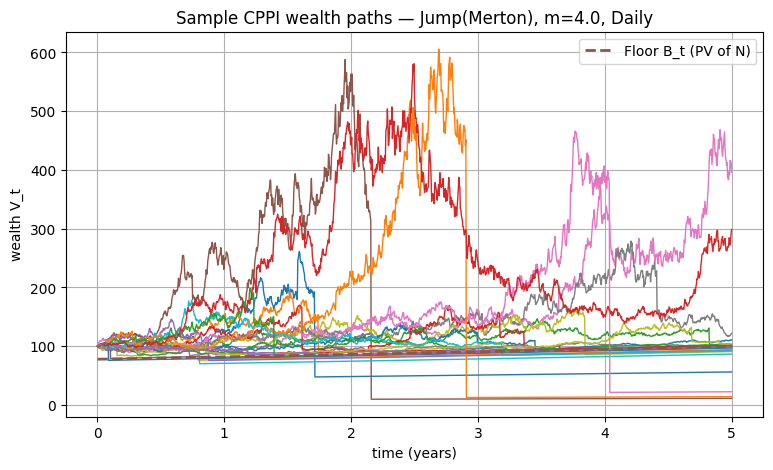

In [ ]:
# 12) Plot a few sample wealth paths + floor

def plot_sample_paths(gross_returns: np.ndarray, model_label: str, m: float, freq_name: str, n_show: int = 20):
    every = REBAL_FREQ[freq_name]
    res = run_cppi(
        gross_returns=gross_returns,
        m=m,
        N=N_GUARANTEE,
        V0=V0,
        r=RISK_FREE,
        T=T_YEARS,
        dt=DT,
        rebalance_every=every,
        borrow_spread=BORROW_SPREAD,
        tcost=TCOST,
        leverage_cap=None,
        store_paths=True,
    )
    Vp = res.V_paths
    idx = np.random.default_rng(SEED).choice(Vp.shape[0], size=min(n_show, Vp.shape[0]), replace=False)

    times = np.linspace(0.0, T_YEARS, N_STEPS + 1)
    B = floor_value(times, N_GUARANTEE, RISK_FREE, T_YEARS)

    plt.figure()
    for i in idx:
        plt.plot(times, Vp[i, :], linewidth=1)
    plt.plot(times, B, linestyle="--", linewidth=2, label="Floor B_t (PV of N)")
    plt.title(f"Sample CPPI wealth paths — {model_label}, m={m}, {freq_name}")
    plt.xlabel("time (years)")
    plt.ylabel("wealth V_t")
    plt.legend()
    plt.show()

plot_sample_paths(G_jump, "Jump(Merton)", m=4.0, freq_name="Daily", n_show=25)

Sample paths illustrate the CPPI mechanism (dynamic exposure and floor tracking) and show how jump losses can trigger lock-in and monetization effects.

### Conclusion

We implement a discrete CPPI strategy with floor $B_t = N e^{-r(T-t)}$ and risky exposure $E_t = m (V_t - B_t)^+$, rebalanced at daily/weekly/monthly frequencies. Under GBM, shortfall risk is mainly induced by discrete rebalancing and decreases with more frequent trading, while under Merton jumps it is driven by rare but large downward moves and depends much less on rebalancing frequency. Increasing the multiple $m$ raises upside but amplifies tail risk, and a leverage cap $E_t \le L_{\max} V_t$ reduces shortfall at the cost of lower expected terminal wealth. OBPI (bond + ATM call) provides a benchmark with $V_T \ge N$ at maturity by construction, highlighting the difference between dynamic and option-based portfolio insurance.

**Main results (20,000 paths; $T=5$, $r=5\%$, $\mu=8\%$, $\sigma=20\%$):** under GBM, gap risk mainly comes from discrete rebalancing (monthly rebalancing + large $m$), whereas under jumps $(\lambda=1,\mu_J=-0.12,\sigma_J=0.18)$ tail risk increases sharply with $m$ and is only weakly mitigated by higher rebalancing frequency. A leverage cap reduces tail risk materially under jumps, at the cost of lower upside.